# EDA 2 — Target and browser analysis

This notebook studies the dependent variable `util` (the user to predict) and
the only explicit metadata feature, `navigateur` (the browser).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from be_ml.data import read_ds

train = read_ds("train")
test = read_ds("test")

## The target `util`

A string identifier per user (e.g. `skm`, `nuh`). The task is **multi-class
classification with 247 classes**, and the classes are imbalanced: some users
appear in up to 75 sessions while others appear in only 4.

In [2]:
target = train["util"]
counts = target.value_counts()

print(f"distinct users : {target.nunique()}")
print(f"total sessions : {len(target)}")
print(f"imbalance ratio (max/min class size) : {counts.max() / counts.min():.2f}")
print(f"majority-class baseline accuracy      : {counts.max() / len(target):.3f}  (class '{counts.idxmax()}')")
print()
counts.describe().round(1).to_string()

distinct users : 247
total sessions : 3279
imbalance ratio (max/min class size) : 18.75
majority-class baseline accuracy      : 0.023  (class 'skm')



'count    247.0\nmean      13.3\nstd        8.9\nmin        4.0\n25%        7.0\n50%       12.0\n75%       16.0\nmax       75.0'

In [3]:
print("top 10 users by number of sessions:")
print(counts.head(10).to_string())
print("\nrarest users:")
print(counts.tail(10).to_string())

top 10 users by number of sessions:
util
skm    75
slq    71
cjr    46
flj    42
hjs    37
vfo    35
shh    34
nqg    34
fwf    33
kwi    31

rarest users:
util
azn    4
rff    4
jkt    4
fyg    4
jew    4
zll    4
itt    4
lra    4
bez    4
crn    4


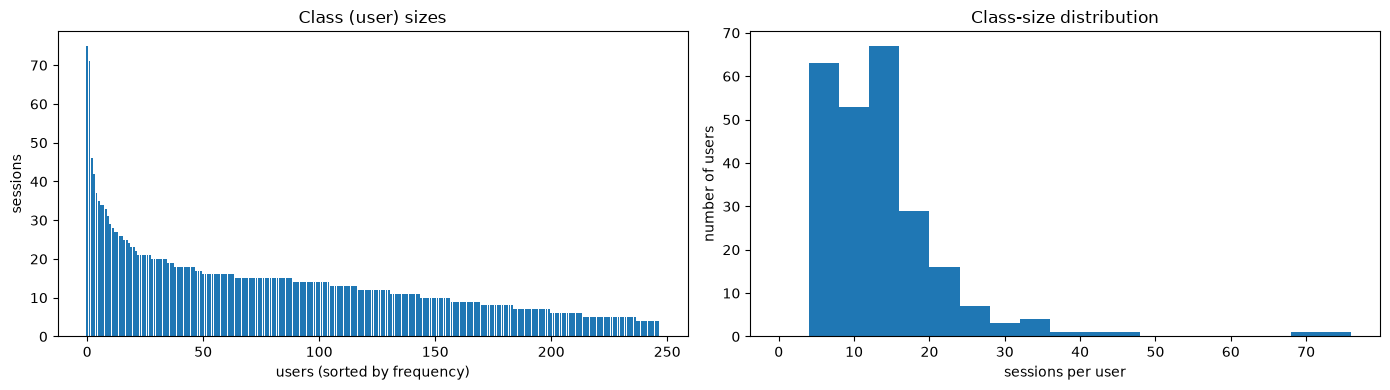

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].bar(range(len(counts)), counts.values)
axs[0].set(xlabel="users (sorted by frequency)", ylabel="sessions", title="Class (user) sizes")
axs[1].hist(counts.values, bins=range(0, counts.max() + 5, 4))
axs[1].set(xlabel="sessions per user", ylabel="number of users", title="Class-size distribution")
plt.tight_layout()
plt.show()

### How many examples per class?

Even the rarest user still has a few sessions, which is good for learning, but
the imbalance means **accuracy alone is misleading**: always predict the
majority class and you already get ~2.6%. Prefer macro-F1 / balanced accuracy.

In [5]:
for k in [4, 5, 10, 20, 30, 50]:
    print(f"users with >= {k:>2} sessions : {(counts >= k).sum():>3}")

users with >=  4 sessions : 247
users with >=  5 sessions : 237
users with >= 10 sessions : 157
users with >= 20 sessions :  35
users with >= 30 sessions :  10
users with >= 50 sessions :   2


## The browser `navigateur`

Only four browsers exist. Their share is very similar in train and test, which
confirms the two sets come from the same population.

In [6]:
browser_train = train["navigateur"].value_counts()
browser_test = test["navigateur"].value_counts()
comparison = pd.DataFrame({"train": browser_train, "test": browser_test}).fillna(0).astype(int)
comparison["train_%"] = (100 * comparison["train"] / comparison["train"].sum()).round(1)
comparison["test_%"] = (100 * comparison["test"] / comparison["test"].sum()).round(1)
comparison

,train,test,train_%,test_%
navigateur,,,,
Firefox,1466,147,44.7,45.4
Google Chrome,1339,133,40.8,41.0
Microsoft Edge,451,42,13.8,13.0
Opera,23,2,0.7,0.6


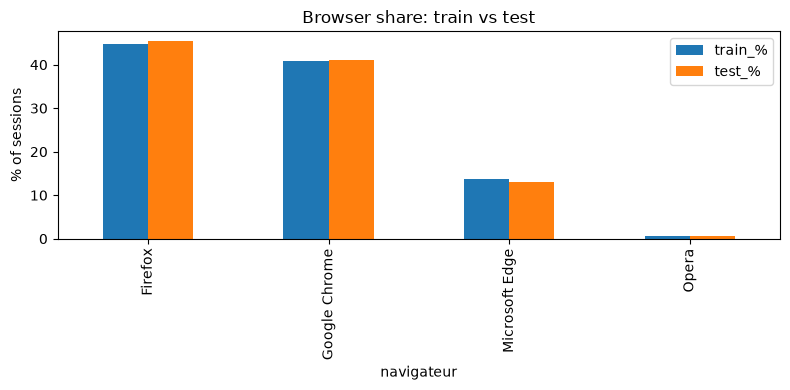

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
comparison[["train_%", "test_%"]].plot.bar(ax=ax)
ax.set(ylabel="% of sessions", title="Browser share: train vs test")
plt.tight_layout()
plt.show()

### Browser vs user

A crucial structural observation: **each user always uses the same browser**
(0 users switch browser). So the browser is a deterministic function of the
user, hence a legitimate but *coarse* feature (4 values for 247 classes).

In [8]:
per_user_browsers = train.groupby("util")["navigateur"].nunique()
print("users using more than one browser:", int((per_user_browsers > 1).sum()), "of", per_user_browsers.size)

users_per_browser = train.drop_duplicates("util")["navigateur"].value_counts()
print("\nnumber of distinct users per browser:")
print(users_per_browser.to_string())

users using more than one browser: 0 of 247

number of distinct users per browser:
navigateur
Firefox           114
Google Chrome      93
Microsoft Edge     39
Opera               1


In [9]:
browser_purity = train.groupby("navigateur")["util"].agg(lambda s: s.value_counts().iloc[0] / len(s))
print("share of the majority user inside each browser (0-1):")
print(browser_purity.round(3).to_string())
print(f"\nmean majority-user share per browser: {browser_purity.mean():.3f}")

share of the majority user inside each browser (0-1):
navigateur
Firefox           0.023
Google Chrome     0.056
Microsoft Edge    0.082
Opera             1.000

mean majority-user share per browser: 0.290


## Takeaways

- 247 imbalanced classes; majority baseline ≈ **2.6%** accuracy.
- Use **macro-F1 / balanced accuracy** in addition to accuracy, and split
  train/validation **by user**.
- `navigateur` is deterministic per user: a useful signal, but alone it can only
  narrow the 247 users down to the ~40-115 users sharing that browser.
- The real discriminative power must come from the **action sequences**.

**Next:** `EDA_03_action_grammar.ipynb` dissects those sequences.